In [1]:
from LMI_util.AFM_analysis import *

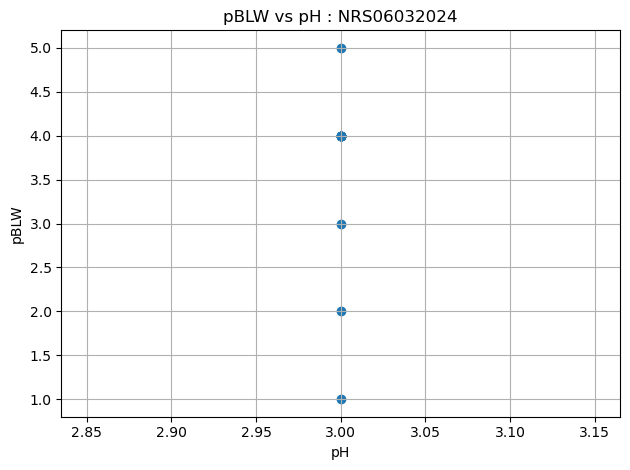

In [3]:
# Test 1: data import and param extraction
root = "C:/Users/robert/Desktop/capstone/capstone_SiC_gratings/data/AFM/NRS06032024"
afm_data = load_all_AFM(root, sample_name = "NRS06032024")
x, y = get_param_pairs_AFM(afm_data, "pH", "pBLW", plot=True)

c:\Users\robert\Desktop\capstone\capstone_SiC_gratings\LMI_util\AFM_analysis.py:134: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=30)


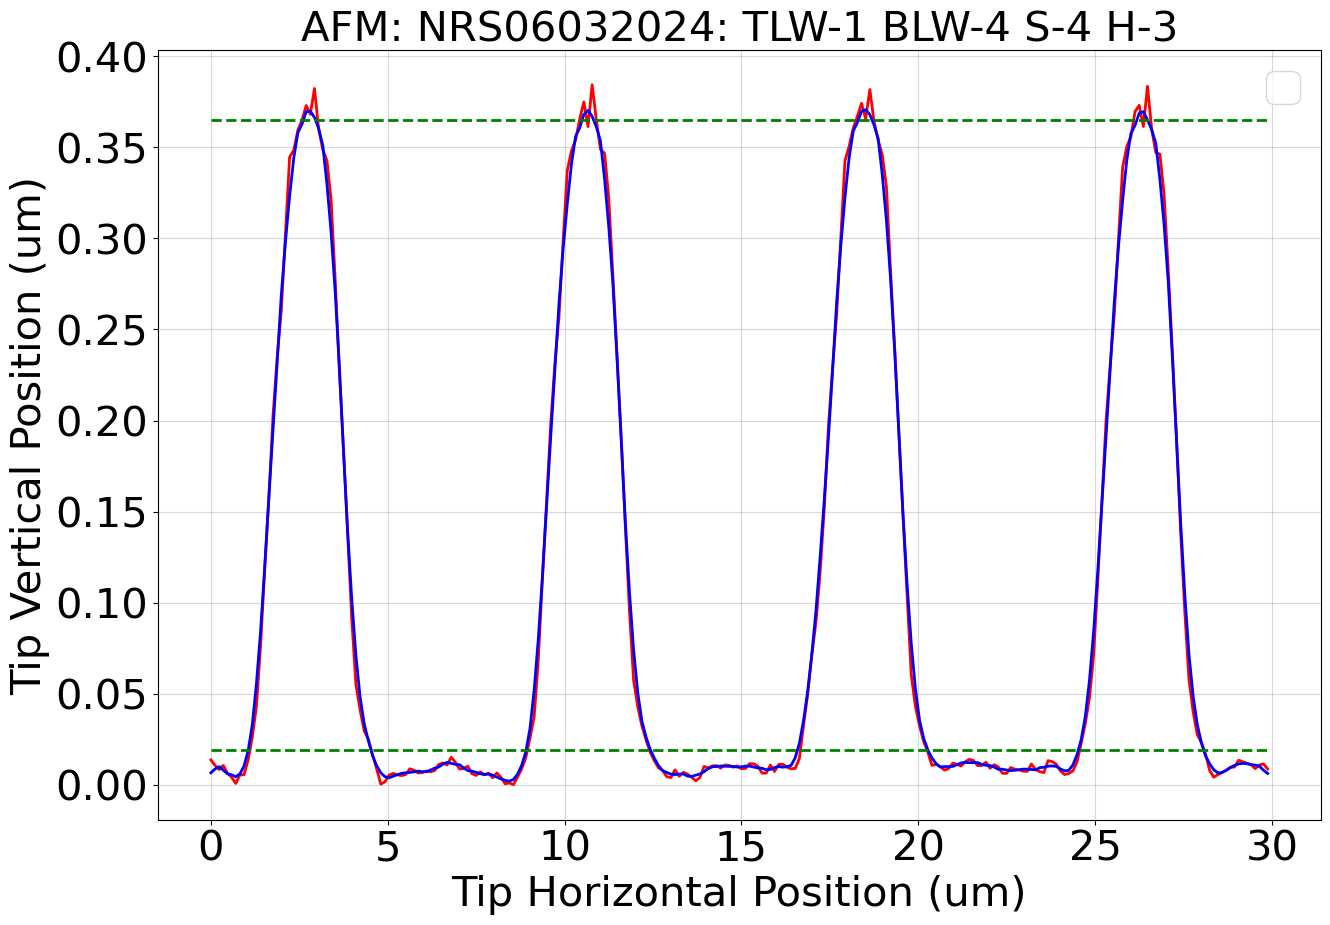

In [ ]:
# Test 2: Raw Data extraction and data smoothing
x, y, sample, grating = get_raw_data_AFM(afm_data, TLW=1, BLW=4, S=4, H=3)
y_smooth = moving_average(y)
plot_single_AFM(x, y, sample, grating, AFMy_smooth=y_smooth, level1=0.05, level2=0.95)

In [ ]:
# Test 3: Extracting TLW and BLW

def width_at_level(x,y,level):
    if x.shape != y.shape:
        raise ValueError("x and y must have same shape")

    s = y - level  # zero crossings when y == level

    crossing_indices = np.where(np.diff(np.sign(s)) != 0)[0]

    if crossing_indices.size < 2:
        raise RuntimeError(
            f"Not enough crossings at level={level}. "
            "Check your data or chosen level."
        )

    xs_cross = []
    for i in crossing_indices:
        x0, x1 = x[i], x[i+1]
        y0, y1 = s[i], s[i+1]
        # avoid division-by-zero just in case
        if y1 == y0:
            continue
        frac = -y0 / (y1 - y0)   # where between i and i+1 we hit 0
        xs_cross.append(x0 + frac * (x1 - x0))

    

    